<a href="https://colab.research.google.com/github/AIZEN-Hado/Market-Sentiment-Trader-Performance/blob/main/Copy_of_Yashsingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== Average PnL by Sentiment =====
classification
Extreme Fear       0.580604
Extreme Greed    238.241451
Fear             128.618052
Greed             56.529349
Neutral           21.146662
Name: closed pnl, dtype: float64

===== Win Rate by Sentiment =====
classification
Extreme Fear     0.287732
Extreme Greed    0.577782
Fear             0.379204
Greed            0.451165
Neutral          0.497710
Name: win, dtype: float64

===== Trade Count by Sentiment =====
classification
Fear             13262
Greed            10300
Extreme Greed     5194
Neutral           2620
Extreme Fear      2266
Name: count, dtype: int64

===== Buy/Sell Distribution =====
side             BUY  SELL
classification            
Extreme Fear    1137  1129
Extreme Greed   1460  3734
Fear            6972  6290
Greed           4819  5481
Neutral          941  1679

===== Top 5 Traders by Profit =====
account
0x430f09841d65beb3f27765503d0f850b8bce7713    1.710000e+12
0x513b8629fe877bb581bf244e326a047b249c4ff1    

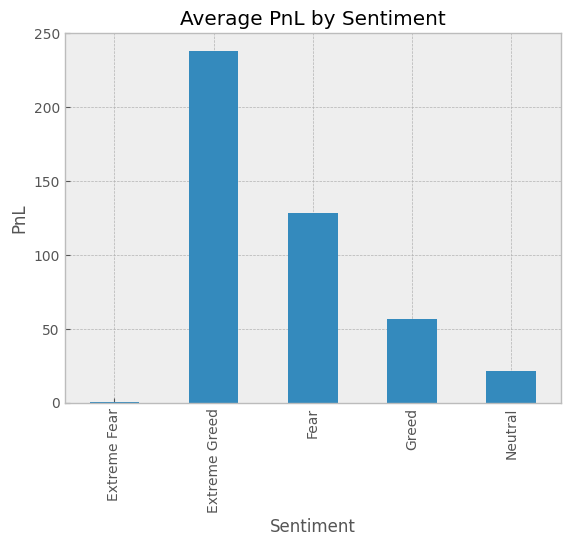

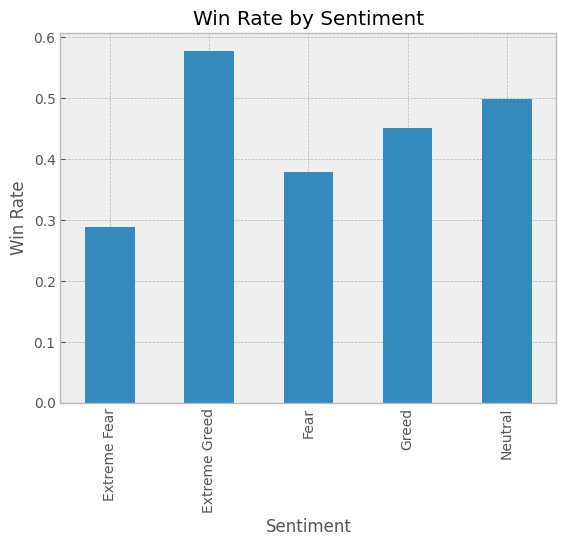

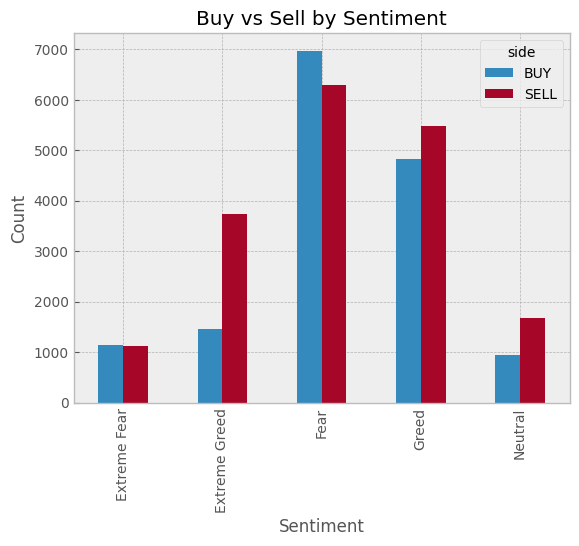

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

trades = pd.read_csv("historical_data.csv", on_bad_lines='skip', low_memory=False)
sentiment = pd.read_csv("fear_greed_index.csv")

trades.columns = trades.columns.str.lower()
sentiment.columns = sentiment.columns.str.lower()

trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'], errors='coerce')
trades['date'] = trades['timestamp ist'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

data = pd.merge(trades, sentiment, on='date', how='left')

data['win'] = data['closed pnl'] > 0

if 'leverage' in data.columns:
    data['leverage_group'] = pd.cut(
        data['leverage'],
        bins=[0, 5, 10, 100],
        labels=['Low', 'Medium', 'High']
    )

print("\n===== Average PnL by Sentiment =====")
print(data.groupby('classification')['closed pnl'].mean())

print("\n===== Win Rate by Sentiment =====")
print(data.groupby('classification')['win'].mean())

print("\n===== Trade Count by Sentiment =====")
print(data['classification'].value_counts())

print("\n===== Buy/Sell Distribution =====")
print(pd.crosstab(data['classification'], data['side']))

if 'leverage_group' in data.columns:
    print("\n===== Leverage vs PnL =====")
    print(data.groupby(['classification', 'leverage_group'])['closed pnl'].mean())

print("\n===== Top 5 Traders by Profit =====")
top_traders = data.groupby('account')['closed pnl'].sum().sort_values(ascending=False).head(5)
print(top_traders)

data.groupby('classification')['closed pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("PnL")
plt.show()

data.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.show()

pd.crosstab(data['classification'], data['side']).plot(kind='bar')
plt.title("Buy vs Sell by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()